# Ejercicio 3

Para la realización de este ejercicio se usó el data set [Penguin Species Dataset](https://www.kaggle.com/datasets/srisyra02/penguin-species-dataset/data) que contiene varios registros de pingüinos de diferentes especies junto con datos como la isla donde se encontraron y medidas de los diferentes pingüinos.

In [13]:
import kagglehub

path = kagglehub.dataset_download("srisyra02/penguin-species-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'penguin-species-dataset' dataset.
Path to dataset files: /kaggle/input/penguin-species-dataset


In [ ]:
import os
import pandas as pd
import numpy as np

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, csv_file[0])
df = pd.read_csv(csv_path)

print(f"Dimensiones del dataset: {df.shape}\n")
display(df.head())

## Features y Rótulo

Este dataset busca clasificar a diferentes especies de pingüinos por lo que es de esperar que el rótulo del dataset sea la especie de pingüino de cada registro. En este caso se identifican únicamente 3 especies: Adelie, Gentoo, y Chinstrap.

In [22]:
target_column = 'species' if 'species' in df.columns else df.columns[-1]
print(f"Rótulo: '{target_column}'")
print("\nDistribución del rótulo:")
print(df[target_column].value_counts(dropna=False))

Rótulo: 'species'

Distribución del rótulo:
species
Adelie       461
Gentoo       288
Chinstrap    251
Name: count, dtype: int64


En el data set se encuentran el doble de Adelies que cualquier otra especie, sin embargo, se puede considerar bien distribuido ya que cada especie tiene una cantidad considerable de registros.

Por otro lado, los features son los siguientes:

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            1000 non-null   object 
 1   island             1000 non-null   object 
 2   culmen_length_mm   990 non-null    float64
 3   culmen_depth_mm    990 non-null    float64
 4   flipper_length_mm  990 non-null    float64
 5   body_mass_g        990 non-null    float64
 6   sex                990 non-null    object 
dtypes: float64(4), object(3)
memory usage: 54.8+ KB


En 5 de los 7 features (sin contar species) existen 10 registros sin información (nulos) pero no supone un problema ya que la gran mayoria de los registros parecen estar completos.

Los features son, isla, mediciones del pico (culmen) de los pingüinos, mediciones de las aletas, peso corporal y sexo.

## Entrenamiento de Modelo

Se entrena un modelo simple de árbol de desición para este dataset. Lo primero es limpiar los datos, ya que hay registros sin datos, estos se quitan directamente.

Luego se separan los features del rotulo, se convierten los valores categóricos a numéricos. Se separan datos de entrenamiento y de prueba y se entrena el modelo. Para esto se importa DecisionTreeClassifier de sklearn. Finalmente, se evalua la precisión del modelo.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

df_clean = df.dropna().copy()

y = df_clean[target_column]
X = df_clean.drop(columns=[target_column])
# Convertir variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Precisión (Accuracy):", accuracy_score(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Precisión (Accuracy): 0.9947643979057592

Reporte de Clasificación:
              precision    recall  f1-score   support

      Adelie       1.00      0.99      0.99        88
   Chinstrap       0.98      1.00      0.99        48
      Gentoo       1.00      1.00      1.00        55

    accuracy                           0.99       191
   macro avg       0.99      1.00      0.99       191
weighted avg       0.99      0.99      0.99       191



## Ejemplos de Clasificación

Ya con el modelo podemos ver la toma de desiciones y ver que variables considera importantes para la clasificación de las especies.

In [26]:
ejemplos_indices = X_test.sample(3, random_state=10).index
ejemplos_X = X_test.loc[ejemplos_indices]
ejemplos_y_real = y_test.loc[ejemplos_indices]
ejemplos_pred = model.predict(ejemplos_X)

for idx, real, pred in zip(ejemplos_indices, ejemplos_y_real, ejemplos_pred):
    print(f"\nID del Pingüino: {idx}")
    print(f"Datos del pingüino:\n{df_clean.loc[idx].to_dict()}")
    print(f"Especie Real: {real} | Predicción del Modelo: {pred}")


ID del Pingüino: 110
Datos del pingüino:
{'species': 'Adelie', 'island': 'Dream', 'culmen_length_mm': 37.5, 'culmen_depth_mm': 15.7, 'flipper_length_mm': 187.0, 'body_mass_g': 3818.0, 'sex': 'Female'}
Especie Real: Adelie | Predicción del Modelo: Adelie

ID del Pingüino: 676
Datos del pingüino:
{'species': 'Adelie', 'island': 'Dream', 'culmen_length_mm': 41.4, 'culmen_depth_mm': 19.3, 'flipper_length_mm': 185.0, 'body_mass_g': 3761.0, 'sex': 'Female'}
Especie Real: Adelie | Predicción del Modelo: Adelie

ID del Pingüino: 865
Datos del pingüino:
{'species': 'Chinstrap', 'island': 'Dream', 'culmen_length_mm': 49.7, 'culmen_depth_mm': 19.0, 'flipper_length_mm': 193.0, 'body_mass_g': 3975.0, 'sex': 'Male'}
Especie Real: Chinstrap | Predicción del Modelo: Chinstrap


En este ejemplo de uso, podemos ver como en los tres casos aleatorios obtuvo la clasificación correcta. Esto demuestra que los datos de entrenamiento permitieron al modelo predecir correctamente los resultados.

Para ver las variables que influyen en la toma de las decisiones se realiza el siguiente código:

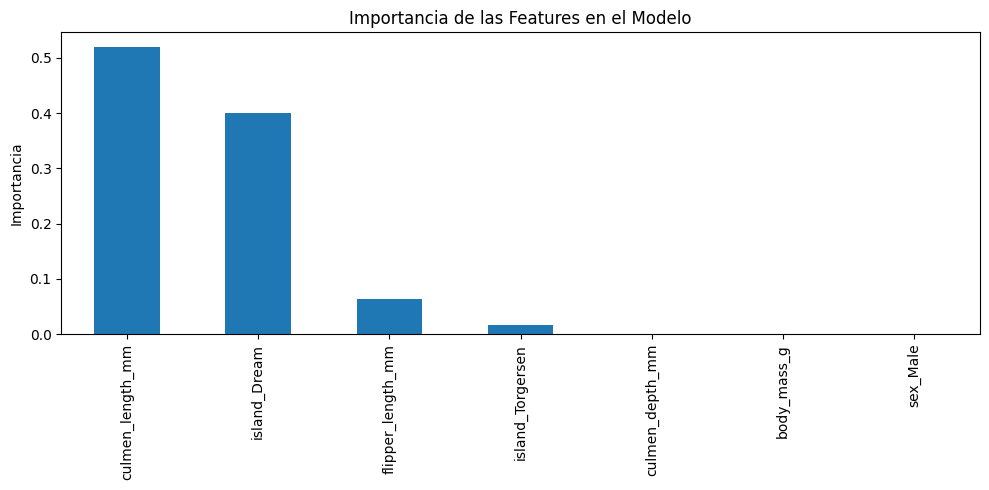

In [28]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns_plot = importances.plot(kind='bar')
plt.title("Importancia de las Features en el Modelo")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

El gráfico muestra como las variables más relevantes para la toma de decisiones son la longitud del pico y la isla donde se encontro y no considera en aboluto el peso ni el sexo del animal.